## 1. Imports and project paths

In [ ]:
from pathlib import Path
from collections import defaultdict
import pickle
import sys

import jax
import jax.numpy as np
from astropy.io import fits

jax.config.update("jax_enable_x64", True)

# Find the project root whether this notebook is launched from
# notebooks/ or from the repository root.
cwd = Path.cwd().resolve()

if cwd.name == "notebooks":
    NOTEBOOK_DIR = cwd
    PROJECT_ROOT = cwd.parent
elif (cwd / "notebooks").exists():
    PROJECT_ROOT = cwd
    NOTEBOOK_DIR = cwd / "notebooks"
else:
    # Fallback: assume current directory is the notebooks folder
    NOTEBOOK_DIR = cwd
    PROJECT_ROOT = cwd.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models import *
from detectors import *
from apertures import *

print("PROJECT_ROOT :", PROJECT_ROOT)
print("NOTEBOOK_DIR :", NOTEBOOK_DIR)


PROJECT_ROOT : /Users/haarshakrishna/hubble
NOTEBOOK_DIR : /Users/haarshakrishna/hubble/FOSE7902


## 2. Pipeline settings

In [ ]:
# DATASET

DATASET = "MAST_10879"

DATA_DIR = ( NOTEBOOK_DIR / "data" / DATASET / "MAST" / "HST" )
RESULTS_DIR = ( PROJECT_ROOT / "results" / DATASET )
RESULTS_DIR.mkdir( parents=True, exist_ok=True )

GRID_NOTEBOOK = "Grid Search.ipynb"
BFGS_NOTEBOOK = "BFGS optimisation.ipynb"
HMC_NOTEBOOK = "HMC sampling.ipynb"


# WHAT TO RUN

FILTERS_TO_RUN = ["F170M"]

# None = every target found in the dataset
TARGETS_TO_RUN = ["U10018"]

# False for the very first test so every stage definitely runs.
# After a successful test, change this to True.
RESUME = True


# PLOTTING

MAKE_GRID_PLOTS = False
MAKE_BFGS_PLOTS = False
MAKE_HMC_PLOT = True
SHOW_HMC_PLOT = False

print("DATA_DIR    :", DATA_DIR)
print("RESULTS_DIR :", RESULTS_DIR)


DATA_DIR    : /Users/haarshakrishna/hubble/FOSE7902/data/MAST_10879/MAST/HST
RESULTS_DIR : /Users/haarshakrishna/hubble/results/MAST_10879


In [ ]:
# from pathlib import Path
# import nbformat

# print("Notebook directory:")
# print(NOTEBOOK_DIR)

# print("\nNotebooks found:\n")

# for path in sorted(NOTEBOOK_DIR.glob("*.ipynb")):

#     print(
#         path.name,
#         "|",
#         path.stat().st_size,
#         "bytes"
#     )

#     try:
#         nbformat.read(
#             path,
#             as_version=4
#         )

#         print("   ✓ valid notebook")

#     except Exception as e:

#         print(
#             "   ✗ INVALID:",
#             type(e).__name__,
#             e
#         )

Notebook directory:
/Users/haarshakrishna/hubble/FOSE7902

Notebooks found:

BFGS optimisation.ipynb | 616438 bytes
   ✓ valid notebook
Grid Search.ipynb | 39538 bytes
   ✓ valid notebook
HMC sampling.ipynb | 51364 bytes
   ✓ valid notebook
binary_grid_search_debug.ipynb | 1294959 bytes
   ✓ valid notebook
run_pipeline.ipynb | 83937 bytes
   ✓ valid notebook


## 3. Load the three cleaned stage notebooks

This brings `run_grid_for_group()`, `run_bfgs_for_group()`, `run_hmc_for_group()` and their helper functions into this notebook.

If this cell says a notebook cannot be found, just correct the three filenames in the previous cell.

In [4]:
def load_stage_notebook(filename):
    path = NOTEBOOK_DIR / filename

    if not path.exists():
        raise FileNotFoundError(
            f"Could not find stage notebook:\n{path}\n\n"
            "Change the filename in the settings cell."
        )

    print("Loading:", path.name)
    get_ipython().run_line_magic("run", f'"{path}"')


load_stage_notebook(GRID_NOTEBOOK)
load_stage_notebook(BFGS_NOTEBOOK)
load_stage_notebook(HMC_NOTEBOOK)

required_functions = [
    "run_grid_for_group",
    "run_bfgs_for_group",
    "run_hmc_for_group",
]

for name in required_functions:
    if name not in globals():
        raise RuntimeError(
            f"{name} was not defined after loading the stage notebooks."
        )

print("\nAll three pipeline functions are available.")


Loading: Grid Search.ipynb
Loading: BFGS optimisation.ipynb
Loading: HMC sampling.ipynb

All three pipeline functions are available.


## 4. Central model, Grid, BFGS and HMC configuration

In [ ]:
# COMMON MODEL SETTINGS

MODEL_CONFIG = { "wid": 64, "oversample": 4, "psf_oversample": 4, "nwavels": 20, "npoly": 5, "n_zernikes": 20, }

GRID_CONFIG = {
    **MODEL_CONFIG,

    "n_aberrations": 26,
    "x_min": -5,
    "x_max": 5,
    "y_min": -5,
    "y_max": 5,
    "Nx": 10,
    "Ny": 10,
    "r_min": 0,
    "r_max": 5.0,
    "Nr": 20,
    "theta_min": -180,
    "theta_max": 180,
    "Ntheta": 10,
    "c_min": 1.0,
    "c_max": 10.0,
    "Nc": 5,
}


BFGS_CONFIG = {
    "max_steps": 20,
    "n_zernikes": MODEL_CONFIG["n_zernikes"],
    "oversample": MODEL_CONFIG["oversample"],

    "single_bfgs_keys": [ "positions", "spectrum", "aberrations", "cold_mask_shift", "bias", "despace", "mag", ],

    "binary_bfgs_keys": [ "positions", "separation", "position_angle", "primary_spectrum", "secondary_spectrum", "aberrations", "cold_mask_shift", "bias", "despace", "mag", ],

    "single_scale_values": {
        "positions": 0.1,
        "spectrum": 50.0,
        "aberrations": 1.0,
        "cold_mask_shift": 0.1,
        "bias": 0.01,
        "despace": 1.0,
        "mag": 0.1,
    },

    "binary_scale_values": {
        "positions": 0.1,
        "separation": 0.1,
        "position_angle": 1.0,
        "primary_spectrum": 50.0,
        "secondary_spectrum": 50.0,
        "aberrations": 1.0,
        "cold_mask_shift": 0.1,
        "bias": 0.01,
        "despace": 1.0,
        "mag": 0.1,
    },
}


HMC_CONFIG = {
    "num_warmup": 5,
    "num_samples": 5,
    "seed": 0,
}

print("Configuration ready.")


Configuration ready.


## 5. Build the shared NICMOS model objects

In [ ]:
wid = MODEL_CONFIG["wid"]
oversample = MODEL_CONFIG["oversample"]
psf_oversample = MODEL_CONFIG["psf_oversample"]
nwavels = MODEL_CONFIG["nwavels"]
npoly = MODEL_CONFIG["npoly"]
n_zernikes = MODEL_CONFIG["n_zernikes"]

# Same spectrum basis used in the current notebooks
spectrum_basis = np.ones( (nwavels, npoly) )

# Grid optics
grid_optics = NICMOSOptics( 512, wid, oversample )
grid_oversampled_optics = NICMOSOptics( 512, wid, oversample * psf_oversample, psf_oversample=psf_oversample )


# Full optics used by BFGS and HMC

science_optics = NICMOSSecondaryFresnelOptics( 512, wid, oversample, mag=3.3, defocus=0.0, despace=0.0, n_zernikes=n_zernikes )
detector = NICMOSDetector( oversample, wid )
print("Model objects ready.")


Model objects ready.


## 6. Discover every calibrated FITS file and separate by target + filter

The important line here is:

```python
key = (target, filt)
```

so F110W, F145M, F170M, etc. are handled independently.

In [ ]:
files = sorted( DATA_DIR.glob("*_cal.fits") )

if len(files) == 0:
    raise FileNotFoundError(
        f"No *_cal.fits files found in:\n{DATA_DIR}"
    )

print(f"Found {len(files)} calibrated FITS file(s).\n")

groups = defaultdict( lambda: { "single": [], "binary": [], "files": [], } )

for fname in files:

    with fits.open(fname) as hdul:
        target = str( hdul[0].header["TARGNAME"] ).strip()
        filt = str( hdul[0].header["FILTER"] ).strip()

    # Optional target filtering
    if (
        TARGETS_TO_RUN is not None
        and target not in TARGETS_TO_RUN
    ):
        continue

    # Optional filter filtering
    if (
        FILTERS_TO_RUN is not None
        and filt not in FILTERS_TO_RUN
    ):
        continue

    exp_single = exposure_from_file( str(fname), SinglePointFit( spectrum_basis, filt ), crop=wid )
    exp_binary = exposure_from_file( str(fname), BinaryFit( spectrum_basis, filt ), crop=wid )

    key = ( target, filt )

    groups[key]["single"].append( exp_single )
    groups[key]["binary"].append( exp_binary )
    groups[key]["files"].append( str(fname) )

    print( fname.name, "→", target, "→", filt )

if len(groups) == 0:
    raise RuntimeError(
        "No target/filter groups matched the current selection."
    )


Found 120 calibrated FITS file(s).

Version 4.4.1
170 77
Version 4.4.1
170 77
n9nk01n2q_cal.fits → U10018 → F170M
Version 4.4.1
216 77
Version 4.4.1
216 77
n9nk01nbq_cal.fits → U10018 → F170M


## 7. Check the groups before doing any expensive fitting

In [10]:
print("=" * 70)
print("GROUPS TO RUN")
print("=" * 70)

for (target, filt), group in sorted(groups.items()):

    print(
        f"{target:30s} | "
        f"{filt:8s} | "
        f"{len(group['single'])} exposure(s)"
    )


GROUPS TO RUN
U10018                         | F170M    | 2 exposure(s)


## 8. Run Grid → BFGS → HMC


######################################################################
TARGET    : U10018
FILTER    : F170M
EXPOSURES : 2
######################################################################

Loading existing Grid result:
/Users/haarshakrishna/hubble/results/MAST_10879/U10018/F170M/grid.pkl

RUNNING BFGS
TARGET: U10018
FILTER: F170M
Grid results received
Single loss before: 17234722.988242753
Binary loss before: 21150919.253496658

Running single BFGS...

Running binary BFGS...

RESULTS
----------------------------------------
Single: 17234722.988242753 → 17234722.988242753
Binary: 21150919.253496658 → 21150919.253496658
Single finite: True
Binary finite: True

Saved: /Users/haarshakrishna/hubble/results/MAST_10879/U10018/F170M/bfgs.pkl

RUNNING HMC
TARGET: U10018
FILTER: F170M
Loaded BFGS parameters

HMC settings
Warmup : 5
Samples: 5
Seed   : 0

Running SINGLE HMC...


sample: 100%|██████████| 10/10 [00:05<00:00,  1.81it/s, 1 steps of size 4.00e-03. acc. prob=0.00]



Running BINARY HMC...


sample: 100%|██████████| 10/10 [00:09<00:00,  1.04it/s, 1 steps of size 4.00e-03. acc. prob=0.00]


Single samples:
positions (5, 2, 2)
spectrum (5, 1, 5)

Binary samples:
position_angle (5,)
positions (5, 2, 2)
primary_spectrum (5, 1, 5)
secondary_spectrum (5, 1, 5)
separation (5,)

Single divergences: 5
Binary divergences: 5

SINGLE HMC SUMMARY

                    mean       std    median      5.0%     95.0%     n_eff     r_hat
positions[0,0]     -0.56      0.00     -0.56     -0.56     -0.56       nan       nan
positions[0,1]     -0.56      0.00     -0.56     -0.56     -0.56       nan       nan
positions[1,0]     -0.56      0.00     -0.56     -0.56     -0.56       nan       nan
positions[1,1]     -0.56      0.00     -0.56     -0.56     -0.56       nan       nan
 spectrum[0,0]   1335.23      0.00   1335.23   1335.23   1335.23       nan       nan
 spectrum[0,1]      0.00      0.00      0.00      0.00      0.00       nan       nan
 spectrum[0,2]      0.00      0.00      0.00      0.00      0.00       nan       nan
 spectrum[0,3]      0.00      0.00      0.00      0.00      0.00     

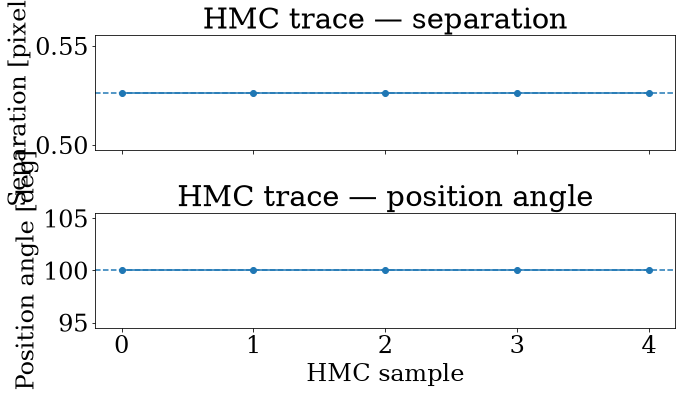

Saved plot: /Users/haarshakrishna/hubble/results/MAST_10879/U10018/F170M/plots/hmc_comparison.png
Saved: /Users/haarshakrishna/hubble/results/MAST_10879/U10018/F170M/hmc.pkl

PIPELINE COMPLETE
✓ U10018 | F170M

Results directory:
/Users/haarshakrishna/hubble/results/MAST_10879


In [ ]:
pipeline_results = {}


def safe_name(value): return ( str(value) .replace(" ", "_") .replace("/", "_") )


for (target, filt), group in sorted(groups.items()):

    print()
    print("#" * 70)
    print("TARGET    :", target)
    print("FILTER    :", filt)
    print("EXPOSURES :", len(group["single"]))
    print("#" * 70)

    exposures_single = group["single"]
    exposures_binary = group["binary"]

    group_dir = ( RESULTS_DIR / safe_name(target) / filt )
    group_dir.mkdir( parents=True, exist_ok=True )
    grid_path = ( group_dir / "grid.pkl" )
    bfgs_path = ( group_dir / "bfgs.pkl" )
    hmc_path = ( group_dir / "hmc.pkl" )

    
    # GRID

    if RESUME and grid_path.exists():

        print("\nLoading existing Grid result:")
        print(grid_path)

        with open(
            grid_path,
            "rb"
        ) as f:
            grid_output = pickle.load(f)

    else:

        grid_output = run_grid_for_group(
            target=target,
            filt=filt,
            exposures_single=exposures_single,
            exposures_binary=exposures_binary,
            optics=grid_optics,
            oversampled_optics=grid_oversampled_optics,
            detector=detector,
            spectrum_basis=spectrum_basis,
            config=GRID_CONFIG,
            results_dir=RESULTS_DIR,
            make_plots=MAKE_GRID_PLOTS,
            save=True,
        )


    # BFGS
   
    if RESUME and bfgs_path.exists():

        print("\nLoading existing BFGS result:")
        print(bfgs_path)

        with open(
            bfgs_path,
            "rb"
        ) as f:
            bfgs_output = pickle.load(f)

    else:

        bfgs_output = run_bfgs_for_group(
            target=target,
            filt=filt,
            exposures_single=exposures_single,
            exposures_binary=exposures_binary,
            grid_output=grid_output,
            optics=science_optics,
            detector=detector,
            config=BFGS_CONFIG,
            results_dir=RESULTS_DIR,
            make_plots=MAKE_BFGS_PLOTS,
            save=True,
        )


    # HMC

    if RESUME and hmc_path.exists():

        print("\nLoading existing HMC result:")
        print(hmc_path)

        with open(
            hmc_path,
            "rb"
        ) as f:
            hmc_output = pickle.load(f)

    else:

        (
            hmc_output,
            single_mcmc,
            binary_mcmc,
            model_single,
            model_binary,
        ) = run_hmc_for_group(
            target=target,
            filt=filt,
            exposures_single=exposures_single,
            exposures_binary=exposures_binary,
            bfgs_output=bfgs_output,
            optics=science_optics,
            detector=detector,
            config=HMC_CONFIG,
            results_dir=RESULTS_DIR,
            save=True,
            make_plot=MAKE_HMC_PLOT,
            show_plot=SHOW_HMC_PLOT,
        )


    pipeline_results[ (target, filt) ] = { "grid": grid_output, "bfgs": bfgs_output, "hmc": hmc_output, }


print()
print("=" * 70)
print("PIPELINE COMPLETE")
print("=" * 70)

for target, filt in pipeline_results:
    print("✓", target, "|", filt)

print("\nResults directory:")
print(RESULTS_DIR)


## 9. Inspect the saved output structure

Each target/filter should end up as:

```text
results/
└── MAST_10143/
    └── TARGET/
        └── F170M/
            ├── grid.pkl
            ├── bfgs.pkl
            ├── hmc.pkl
            └── plots/
                └── hmc_comparison.png
```


In [12]:
for (target, filt) in pipeline_results:

    group_dir = (
        RESULTS_DIR
        / safe_name(target)
        / filt
    )

    print()
    print(target, "|", filt)

    if group_dir.exists():
        for path in sorted(group_dir.rglob("*")):
            if path.is_file():
                print(
                    "  ",
                    path.relative_to(RESULTS_DIR)
                )



U10018 | F170M
   U10018/F170M/bfgs.pkl
   U10018/F170M/grid.pkl
   U10018/F170M/hmc.pkl
   U10018/F170M/plots/hmc_comparison.png
